In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pumpkins = pd.read_csv('../data/US-pumpkins.csv')

pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [3]:
# Filtramos sobre tu variable 'pumpkins' para dejar solo los paquetes que tengan 'bushel'
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=False, na=False)]

# Comprobamos cuántas filas nos quedan en total
print("Filas que quedan después de filtrar:", len(pumpkins))

# Mostramos el resultado en pantalla
pumpkins.head()

Filas que quedan después de filtrar: 415


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [4]:
# Comprobamos cuántos valores nulos (vacíos) hay en cada columna
pumpkins.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [5]:
# Columnas con las que nos quedamos
columns_to_keep = ['Package', 'Date', 'Low Price', 'High Price']
pumpkins = pumpkins[columns_to_keep]

pumpkins.head()

,Package,Date,Low Price,High Price
70,1 1/9 bushel cartons,9/24/16,15.0,15.0
71,1 1/9 bushel cartons,9/24/16,18.0,18.0
72,1 1/9 bushel cartons,10/1/16,18.0,18.0
73,1 1/9 bushel cartons,10/1/16,17.0,17.0
74,1 1/9 bushel cartons,10/8/16,15.0,15.0


In [6]:
# 1. Calculamos el precio medio sumando mínimo y máximo y dividiendo entre 2
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

# 2. Extraemos el mes de la fecha. Usamos pd.DatetimeIndex para aislar el número del mes (1 al 12)
month = pd.DatetimeIndex(pumpkins['Date']).month

# 3. Creamos un nuevo DataFrame limpio con estos datos procesados
new_pumpkins = pd.DataFrame({
    'Month': month, 
    'Package': pumpkins['Package'], 
    'Low Price': pumpkins['Low Price'],
    'High Price': pumpkins['High Price'], 
    'Price': price
})

new_pumpkins.head()

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.0,15.0,15.0
71,9,1 1/9 bushel cartons,18.0,18.0,18.0
72,10,1 1/9 bushel cartons,18.0,18.0,18.0
73,10,1 1/9 bushel cartons,17.0,17.0,17.0
74,10,1 1/9 bushel cartons,15.0,15.0,15.0


In [7]:
# Si el paquete es de 1 1/9 de bushel, dividimos el precio entre 1.111 para saber cuánto cuesta 1 bushel entero
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price / (1 + 1/9)

# Si el paquete es de 1/2 bushel, multiplicamos el precio por 2 (o dividimos entre 0.5) para saber cuánto costaría el bushel entero
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price / (1/2)

# Vemos el resultado final de la limpieza
new_pumpkins.head()

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.0,15.0,13.5
71,9,1 1/9 bushel cartons,18.0,18.0,16.2
72,10,1 1/9 bushel cartons,18.0,18.0,16.2
73,10,1 1/9 bushel cartons,17.0,17.0,15.3
74,10,1 1/9 bushel cartons,15.0,15.0,13.5


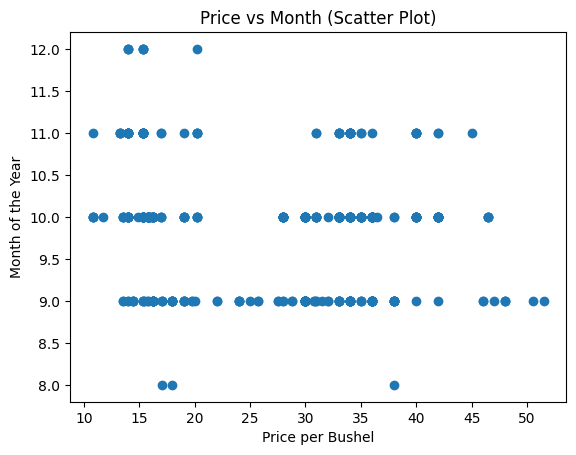

In [8]:
# Sacamos las columnas de los precios normalizados y los meses
price = new_pumpkins.Price
month = new_pumpkins.Month

# Pintamos un punto negro por cada registro de la tabla
plt.scatter(price, month)

# Añadimos etiquetas para entender qué es cada eje
plt.xlabel("Price per Bushel")
plt.ylabel("Month of the Year")
plt.title("Price vs Month (Scatter Plot)")

# Mostramos el resultado en pantalla
plt.show()

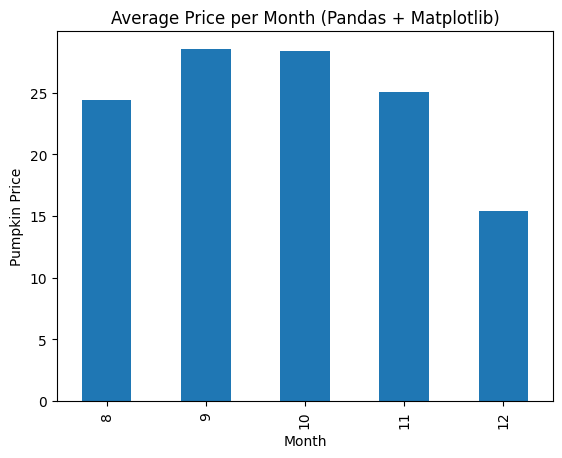

In [9]:
# Agrupamos por mes, sacamos la media de la columna Price y lo pintamos en barras
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')

# Añadimos el título del eje vertical
plt.ylabel("Pumpkin Price")
plt.title("Average Price per Month (Pandas + Matplotlib)")

# Renderizamos la gráfica
plt.show()